# Airline Flight Delay Prediction and Analysis Using Machine Learning

**Type:** Binary Classification
**Dataset:** 2015 Flight Delays and Cancellations (U.S. DOT / BTS, via Kaggle)

## 2. Project Objective

Build an end-to-end machine learning system that predicts whether a scheduled
flight will be significantly delayed (arrival delay of 15+ minutes), using
**only information available before the flight operates**.

**Research question:** Can we predict whether a scheduled flight will be
delayed using pre-flight information alone?

## 3. Business Problem

Flight delays create cascading costs for airlines (crew scheduling, gate
availability, downstream flight delays), airports (congestion), and
passengers (missed connections, lost time). A model that flags high delay-risk
flights at scheduling time -- before any operational data exists -- could
support proactive staffing, more conservative connection-time recommendations,
and clearer passenger communication.

This project restricts itself to information genuinely available before
departure, so the resulting model reflects a realistic pre-flight prediction
scenario rather than one that leaks post-flight knowledge.

## 4. Dataset Description

**Source:** U.S. Department of Transportation / Bureau of Transportation
Statistics, hosted on Kaggle: https://www.kaggle.com/datasets/usdot/flight-delays

Three files are used:

- `flights.csv` -- ~5.8 million individual flight records for 2015 (main file)
- `airlines.csv` -- lookup table mapping airline IATA code to full name
- `airports.csv` -- lookup table mapping airport IATA code to name/city/state/coordinates

`flights.csv` is not included in the GitHub repository due to its size
(~600MB); see `data/README.md` for download instructions.

**Confirmed schema** (verified against the actual downloaded file):
`YEAR, MONTH, DAY, DAY_OF_WEEK, AIRLINE, FLIGHT_NUMBER, TAIL_NUMBER,
ORIGIN_AIRPORT, DESTINATION_AIRPORT, SCHEDULED_DEPARTURE, DEPARTURE_TIME,
DEPARTURE_DELAY, TAXI_OUT, WHEELS_OFF, SCHEDULED_TIME, ELAPSED_TIME, AIR_TIME,
DISTANCE, WHEELS_ON, TAXI_IN, SCHEDULED_ARRIVAL, ARRIVAL_TIME, ARRIVAL_DELAY,
DIVERTED, CANCELLED, CANCELLATION_REASON, AIR_SYSTEM_DELAY, SECURITY_DELAY,
AIRLINE_DELAY, LATE_AIRCRAFT_DELAY, WEATHER_DELAY`.

Note this release uses `AIR_SYSTEM_DELAY` and `AIRLINE_DELAY` rather than the
`NAS_DELAY`/`CARRIER_DELAY` names sometimes seen in other copies of this
dataset -- both are excluded as leakage regardless (Section 10).

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


## 6. Project Setup

This notebook can run in **Google Colab** (with Google Drive for storage) or
**locally / in VS Code** (with a local project folder). The cell below detects
the environment and sets `BASE_DIR` accordingly.

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/airline-flight-delay-analysis"
else:
    # Local / VS Code: assumes this notebook lives in notebooks/ inside the project root
    LOCAL_BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    BASE_DIR = LOCAL_BASE_DIR

# Make src/ importable
sys.path.append(os.path.join(BASE_DIR, "src"))

print(f"Running in Colab: {IN_COLAB}")
print(f"BASE_DIR: {BASE_DIR}")

Running in Colab: False
BASE_DIR: d:\airline-flight-delay-analysis


### Joblib temp folder

`RandomizedSearchCV` and other parallel scikit-learn operations write
temporary memory-mapped files to the OS default temp folder, which on
Windows is usually on the `C:` drive -- this can fail with "No space left on
device" if `C:` is nearly full, even when the project's own drive has plenty
of room. This cell redirects joblib's temp folder into the project directory
itself.

In [3]:
# Redirect joblib/sklearn parallel temp files into the project folder,
# avoiding a possibly near-full system drive (common cause of
# "OSError: No space left on device" during RandomizedSearchCV).
JOBLIB_TEMP_DIR = os.path.join(BASE_DIR, "tmp_joblib")
os.makedirs(JOBLIB_TEMP_DIR, exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = JOBLIB_TEMP_DIR

print(f"Joblib temp folder set to: {JOBLIB_TEMP_DIR}")

Joblib temp folder set to: d:\airline-flight-delay-analysis\tmp_joblib


In [4]:
from data_cleaning import (
    drop_cancelled_and_diverted,
    drop_missing_target_rows,
    drop_duplicate_rows,
    validate_scheduled_departure,
    sample_dataset,
    report_missing_values,
)
from feature_engineering import (
    engineer_features,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    ALL_FEATURES,
    LEAKAGE_COLUMNS,
)

print("Project modules imported from src/.")

Project modules imported from src/.


## 7. Load Dataset

Loads `flights.csv` along with the small lookup tables. Ensure `flights.csv`
has been placed in `data/raw/` per `data/README.md` before running this cell.

**Memory note:** the full file has 31 columns; loading all of them at pandas'
default dtypes can require several GB of RAM and has caused MemoryError on
constrained machines during development. This cell loads only the 13 columns
actually used by this project (`usecols`), with memory-efficient dtypes
(`dtype`), cutting memory usage roughly 10-20x versus a naive full load.

In [5]:
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")

flights_path = os.path.join(RAW_DIR, "flights.csv")
airlines_path = os.path.join(RAW_DIR, "airlines.csv")
airports_path = os.path.join(RAW_DIR, "airports.csv")

assert os.path.exists(flights_path), (
    f"flights.csv not found at {flights_path}. "
    "Download it per data/README.md before continuing."
)

USE_COLS = [
    "YEAR", "MONTH", "DAY", "DAY_OF_WEEK", "AIRLINE",
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE", "SCHEDULED_TIME", "DISTANCE",
    "ARRIVAL_DELAY", "CANCELLED", "DIVERTED",
]

DTYPES = {
    "YEAR": "int16",
    "MONTH": "int8",
    "DAY": "int8",
    "DAY_OF_WEEK": "int8",
    "AIRLINE": "category",
    "ORIGIN_AIRPORT": "category",
    "DESTINATION_AIRPORT": "category",
    "SCHEDULED_DEPARTURE": "int16",
    "SCHEDULED_TIME": "float32",
    "DISTANCE": "float32",
    "ARRIVAL_DELAY": "float32",
    "CANCELLED": "int8",
    "DIVERTED": "int8",
}

flights = pd.read_csv(
    flights_path,
    usecols=USE_COLS,
    dtype=DTYPES,
)
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

print(f"flights.csv shape: {flights.shape}")
print(f"Memory usage: {flights.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"airlines.csv shape: {airlines.shape}")
print(f"airports.csv shape: {airports.shape}")

flights.csv shape: (5819079, 13)
Memory usage: 151.3 MB
airlines.csv shape: (14, 2)
airports.csv shape: (322, 7)


## 8. Initial Data Inspection

Basic structural checks: shape, first rows, column names, and data types.

In [6]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,ARRIVAL_DELAY,DIVERTED,CANCELLED
0,2015,1,1,4,AS,ANC,SEA,5,205.0,1448.0,-22.0,0,0
1,2015,1,1,4,AA,LAX,PBI,10,280.0,2330.0,-9.0,0,0
2,2015,1,1,4,US,SFO,CLT,20,286.0,2296.0,5.0,0,0
3,2015,1,1,4,AA,LAX,MIA,20,285.0,2342.0,-9.0,0,0
4,2015,1,1,4,AS,SEA,ANC,25,235.0,1448.0,-21.0,0,0


In [7]:
print("Columns loaded:")
print(flights.columns.tolist())

Columns loaded:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED']


In [8]:
flights.dtypes

YEAR                      int16
MONTH                      int8
DAY                        int8
DAY_OF_WEEK                int8
AIRLINE                category
ORIGIN_AIRPORT         category
DESTINATION_AIRPORT    category
SCHEDULED_DEPARTURE       int16
SCHEDULED_TIME          float32
DISTANCE                float32
ARRIVAL_DELAY           float32
DIVERTED                   int8
CANCELLED                  int8
dtype: object

In [9]:
flights.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0
SCHEDULED_TIME,5819073.0,NaN,NaN,NaN,141.685883,75.210587,18.0,85.0,123.0,173.0,718.0
DISTANCE,5819079.0,NaN,NaN,NaN,822.356567,607.784302,21.0,373.0,647.0,1062.0,4983.0


## 9. Data Quality Analysis

Check missing values, duplicates, and unique-value counts for key columns.

In [10]:
missing_summary = report_missing_values(flights)
missing_summary

,missing_count,missing_pct
ARRIVAL_DELAY,105071,1.81
SCHEDULED_TIME,6,0.00


In [11]:
n_duplicates = flights.duplicated().sum()
print(f"Exact duplicate rows: {n_duplicates:,}")

Exact duplicate rows: 3


In [12]:
for col in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLED", "DIVERTED"]:
    print(f"{col}: {flights[col].nunique()} unique values")

AIRLINE: 14 unique values
ORIGIN_AIRPORT: 628 unique values
DESTINATION_AIRPORT: 629 unique values
CANCELLED: 2 unique values
DIVERTED: 2 unique values


**Interpretation:** `ARRIVAL_DELAY` will have missing values for cancelled or
diverted flights (no valid arrival time exists for them). This is expected
and is handled explicitly in Section 10, not treated as a data error.

## 10. Target Variable Creation

### Data Leakage Rule

This model predicts delay using only information available **before** the
flight operates. Therefore the following post-flight columns are **excluded
from model inputs**, even though one is used to construct the target:

```
ARRIVAL_DELAY, DEPARTURE_DELAY, AIRLINE_DELAY, WEATHER_DELAY,
AIR_SYSTEM_DELAY, SECURITY_DELAY, LATE_AIRCRAFT_DELAY
```

`ARRIVAL_DELAY` is used **only** to build the target label below, then
dropped from the feature set entirely (it was never loaded as an input
column to begin with -- see `USE_COLS` in Section 7). The delay-cause
columns are post-hoc explanations for *why* a flight was delayed -- they
cannot be known before departure, so they are never valid inputs for a
pre-flight prediction model.

### Cleaning applied before target creation

Cancelled and diverted flights have no valid `ARRIVAL_DELAY` and are removed,
with counts logged. Duplicate rows and invalid `SCHEDULED_DEPARTURE`
timestamps are also removed.

In [13]:
flights = drop_duplicate_rows(flights)
flights = drop_cancelled_and_diverted(flights)
flights = drop_missing_target_rows(flights, target_source_col="ARRIVAL_DELAY")
flights = validate_scheduled_departure(flights)

print(f"\nShape after cleaning: {flights.shape}")

Dropped 3 exact duplicate rows.
Dropped 105,071 cancelled/diverted rows (1.81% of data). Reason: no valid ARRIVAL_DELAY target for these flights.
Dropped 0 rows with missing ARRIVAL_DELAY (0.00% of data). Reason: cannot compute target label without this value.
Dropped 0 rows with invalid SCHEDULED_DEPARTURE timestamps (outside valid HHMM range).

Shape after cleaning: (5714005, 13)


In [14]:
flights["Delayed"] = (flights["ARRIVAL_DELAY"] >= 15).astype(int)

print("Target created: Delayed = 1 if ARRIVAL_DELAY >= 15 minutes, else 0")
flights["Delayed"].value_counts()

Target created: Delayed = 1 if ARRIVAL_DELAY >= 15 minutes, else 0


Delayed
0    4650566
1    1063439
Name: count, dtype: int64

## 11. Target Distribution

Class balance matters for model evaluation and metric interpretation
(a naive "always predict Not Delayed" model can still score high accuracy
if the classes are imbalanced -- this is why F1 and ROC-AUC matter more
than accuracy alone, see Section 20).

In [15]:
counts = flights["Delayed"].value_counts()
pct = flights["Delayed"].value_counts(normalize=True) * 100

print("Class counts:")
print(counts)
print("\nClass percentages:")
print(pct.round(2))

Class counts:
Delayed
0    4650566
1    1063439
Name: count, dtype: int64

Class percentages:
Delayed
0    81.39
1    18.61
Name: proportion, dtype: float64


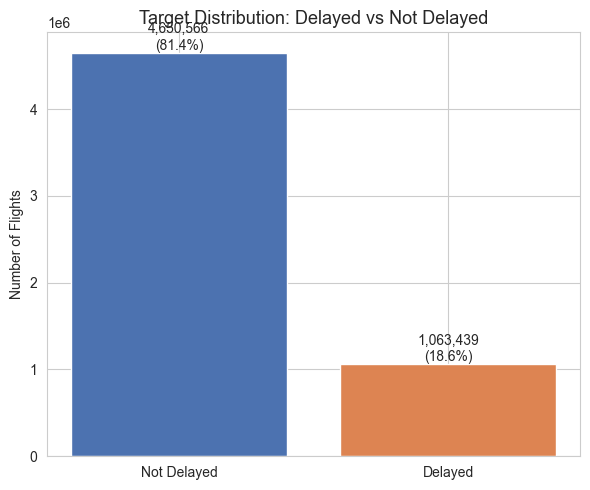

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Not Delayed", "Delayed"]
values = [counts.get(0, 0), counts.get(1, 0)]
colors = ["#4C72B0", "#DD8452"]

ax.bar(labels, values, color=colors)
ax.set_title("Target Distribution: Delayed vs Not Delayed", fontsize=13)
ax.set_ylabel("Number of Flights")
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}\n({v/sum(values)*100:.1f}%)", ha="center", va="bottom")

plt.tight_layout()

results_dir = os.path.join(BASE_DIR, "results")
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "target_distribution.png"), dpi=150)
plt.show()

## 12. Data Cleaning (Continued)

Outlier note: extremely long delays (e.g. several hours) are legitimate
real-world events (severe weather, mechanical issues, etc.) and are **not**
removed as outliers. No blind outlier removal is applied to `ARRIVAL_DELAY` --
the only cleaning applied is the leakage/validity cleaning already performed
in Section 10.

In [17]:
cols_to_check = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "SCHEDULED_DEPARTURE",
                  "SCHEDULED_TIME", "DISTANCE", "MONTH", "DAY", "DAY_OF_WEEK"]
flights[cols_to_check].isnull().sum()

AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
SCHEDULED_TIME         0
DISTANCE               0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
dtype: int64

In [18]:
before = len(flights)
flights = flights.dropna(subset=cols_to_check).copy()
after = len(flights)
print(f"Dropped {before - after:,} rows with missing values in required input columns.")

Dropped 0 rows with missing values in required input columns.


## 13. Feature Engineering

Five engineered features are created, all derived purely from pre-flight
information (see `src/feature_engineering.py` for implementation):

1. **Departure_Hour** -- hour extracted from `SCHEDULED_DEPARTURE` (e.g. 1830 -> 18)
2. **Departure_Minute** -- minute extracted from `SCHEDULED_DEPARTURE`
3. **Is_Weekend** -- 1 if Saturday/Sunday, else 0
4. **Time_of_Day** -- Night (00-04) / Morning (05-11) / Afternoon (12-16) / Evening (17-23)
5. **Distance_Category** -- Short (<500mi) / Medium (500-1500mi) / Long (>1500mi)

Thresholds for `Distance_Category` follow common aviation conventions:
short-haul regional hops, medium-haul typical domestic routes, and
long-haul/transcontinental domestic flights.

In [19]:
flights = engineer_features(flights)
flights[["SCHEDULED_DEPARTURE", "Departure_Hour", "Departure_Minute",
         "DAY_OF_WEEK", "Is_Weekend", "Time_of_Day", "DISTANCE", "Distance_Category"]].head(10)

,SCHEDULED_DEPARTURE,Departure_Hour,Departure_Minute,DAY_OF_WEEK,Is_Weekend,Time_of_Day,DISTANCE,Distance_Category
0,5,0,5,4,0,Night,1448.0,Medium
1,10,0,10,4,0,Night,2330.0,Long
2,20,0,20,4,0,Night,2296.0,Long
3,20,0,20,4,0,Night,2342.0,Long
4,25,0,25,4,0,Night,1448.0,Medium
5,25,0,25,4,0,Night,1589.0,Long
6,25,0,25,4,0,Night,1299.0,Medium
7,30,0,30,4,0,Night,2125.0,Long
8,30,0,30,4,0,Night,1464.0,Medium
9,30,0,30,4,0,Night,1747.0,Long


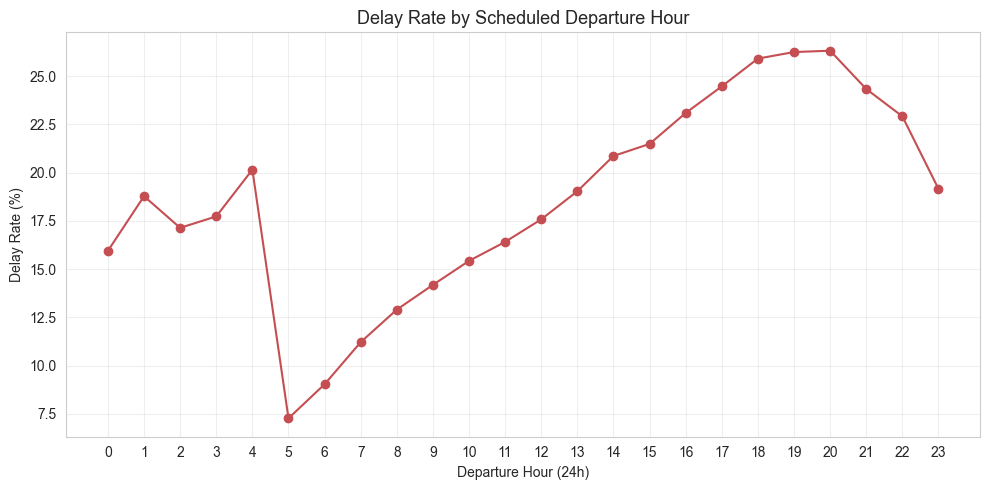

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
delay_by_hour = flights.groupby("Departure_Hour")["Delayed"].mean() * 100

ax.plot(delay_by_hour.index, delay_by_hour.values, marker="o", color="#C44E52")
ax.set_title("Delay Rate by Scheduled Departure Hour", fontsize=13)
ax.set_xlabel("Departure Hour (24h)")
ax.set_ylabel("Delay Rate (%)")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "delay_rate_by_hour.png"), dpi=150)
plt.show()

**Interpretation:** Use this chart to describe the observed pattern (e.g.
whether delay rate trends upward later in the day, which is common in real
airline data due to delay propagation through the day) -- write your actual
observation here once the cell above has been executed on real data.

## 14. Feature Selection

### Selected pre-flight input features

**Numeric:** `DISTANCE`, `SCHEDULED_TIME`, `Departure_Hour`, `Departure_Minute`,
`MONTH`, `DAY`, `DAY_OF_WEEK`

**Categorical:** `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`,
`Is_Weekend`, `Time_of_Day`, `Distance_Category`

**Rationale:**
- `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT` -- different carriers and
  routes/airports have different historical delay patterns (hub congestion,
  operational differences).
- `SCHEDULED_DEPARTURE` (via `Departure_Hour`/`Departure_Minute`) -- delays
  often compound throughout the day.
- `DISTANCE` / `SCHEDULED_TIME` -- longer flights have more schedule buffer
  but also more opportunity for en-route delay.
- `MONTH`, `DAY_OF_WEEK`, `Is_Weekend` -- seasonal and weekly travel patterns
  affect congestion.

Columns explicitly **excluded** as inputs: all columns in `LEAKAGE_COLUMNS`
(see Section 10), plus identifiers like `TAIL_NUMBER` and `FLIGHT_NUMBER`
which are too high-cardinality/sparse to generalize well.

In [21]:
print("Confirming no leakage columns remain in the input feature set:")
overlap = set(ALL_FEATURES).intersection(set(LEAKAGE_COLUMNS))
print(f"Overlap between ALL_FEATURES and LEAKAGE_COLUMNS: {overlap}")
assert len(overlap) == 0, "Leakage column found in feature set!"
print("Confirmed: no leakage columns in ALL_FEATURES.")
print("\nFinal feature list:", ALL_FEATURES)

Confirming no leakage columns remain in the input feature set:
Overlap between ALL_FEATURES and LEAKAGE_COLUMNS: set()
Confirmed: no leakage columns in ALL_FEATURES.

Final feature list: ['DISTANCE', 'SCHEDULED_TIME', 'Departure_Hour', 'Departure_Minute', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'Is_Weekend', 'Time_of_Day', 'Distance_Category']


## 15. Train/Test Split

Given the full dataset is ~5.8 million rows, a reproducible **stratified
sample** is used for modeling. `SAMPLE_SIZE` is set conservatively
(300,000 rows) to keep memory use, disk temp-file size, and runtime
manageable on constrained hardware -- increase it if your machine has more
RAM/disk headroom available. The sample size, method, and random state are
logged below. The test set is held out and untouched until final evaluation
(Section 23).

In [22]:
SAMPLE_SIZE = 300_000  # increase if your machine has more RAM/disk headroom

if len(flights) > SAMPLE_SIZE:
    modeling_df = sample_dataset(flights, n=SAMPLE_SIZE, target_col="Delayed", random_state=RANDOM_STATE)
else:
    modeling_df = flights.copy()
    print(f"Dataset size ({len(flights):,}) is at or below SAMPLE_SIZE; using full dataset.")

assert "Delayed" in modeling_df.columns, "Delayed column missing after sampling!"

Sampling summary:
  Original size:   5,714,005
  Sample size:     300,000
  Method:          stratified by 'Delayed', frac=0.0525
  Random state:    42
  Reason:          full dataset too large for practical model training/tuning on constrained hardware; sampling preserves class balance.


In [23]:
X = modeling_df[ALL_FEATURES]
y = modeling_df["Delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Train shape: (240000, 13)
Test shape:  (60000, 13)

Train target distribution:
Delayed
0    0.813892
1    0.186108
Name: proportion, dtype: float64

Test target distribution:
Delayed
0    0.813883
1    0.186117
Name: proportion, dtype: float64


## 16. Preprocessing Pipeline

Numeric features are standardized; categorical features are one-hot encoded.

**Cardinality control:** `ORIGIN_AIRPORT` and `DESTINATION_AIRPORT` have
~628 unique values each. Naively one-hot encoding both would create 1000+
columns -- as a dense array (required by `HistGradientBoostingClassifier`,
which does not accept sparse input) this can require several GB of RAM and
has caused MemoryError on constrained machines during development.

`max_categories=30` caps each categorical column to its most frequent 30
values; remaining rare categories collapse into a single "infrequent"
bucket. This is a standard, documented tradeoff -- rare airports have too few
samples to learn airport-specific patterns from individually anyway.
`dtype=np.float32` halves memory per cell versus the pandas/sklearn default
of float64.

The preprocessor is fit **only on training data**, then applied to the test
set, to prevent any information leakage from test to train.

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            max_categories=30,
            dtype=np.float32,
        ), CATEGORICAL_FEATURES),
    ]
)

print("Preprocessing pipeline defined.")
print(f"Numeric features: {NUMERIC_FEATURES}")
print(f"Categorical features: {CATEGORICAL_FEATURES}")
print("Categorical encoding: dense OneHotEncoder, max_categories=30, dtype=float32")

Preprocessing pipeline defined.
Numeric features: ['DISTANCE', 'SCHEDULED_TIME', 'Departure_Hour', 'Departure_Minute', 'MONTH', 'DAY', 'DAY_OF_WEEK']
Categorical features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'Is_Weekend', 'Time_of_Day', 'Distance_Category']
Categorical encoding: dense OneHotEncoder, max_categories=30, dtype=float32


## 17. Model 1 -- Logistic Regression

Baseline linear model.

In [25]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


## 18. Model 2 -- Random Forest Classifier

Nonlinear ensemble model; also used later for feature importance.

In [26]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=12, n_jobs=2, random_state=RANDOM_STATE
    ))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 19. Model 3 -- HistGradientBoostingClassifier

A strong, efficient boosting model well-suited to larger tabular datasets.
Requires dense input, which is why the preprocessing pipeline above uses
`sparse_output=False`.

In [27]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_pipeline.fit(X_train, y_train)
print("HistGradientBoosting trained.")

HistGradientBoosting trained.


## 20. Model Comparison

For each model: Accuracy, Precision, Recall, F1-score, and ROC-AUC.

**Metric meanings in this context:**
- **Accuracy** -- overall fraction of correct predictions; can be misleading
  under class imbalance.
- **Precision** -- of flights predicted delayed, how many actually were.
- **Recall** -- of flights that were actually delayed, how many did the model
  catch (matters because *missing* a genuinely delayed flight has real
  operational cost).
- **F1-score** -- harmonic mean of precision and recall; a balanced measure
  under imbalance.
- **ROC-AUC** -- the model's ability to rank delayed flights above non-delayed
  ones across all thresholds, independent of a single cutoff.

In [28]:
def evaluate_pipeline(pipeline, X_test, y_test, name):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }

results = [
    evaluate_pipeline(logreg_pipeline, X_test, y_test, "Logistic Regression"),
    evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest"),
    evaluate_pipeline(hgb_pipeline, X_test, y_test, "HistGradientBoosting"),
]

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(results_dir, "model_comparison.csv"), index=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,HistGradientBoosting,0.815717,0.651934,0.021134,0.040940,0.692363
1,Logistic Regression,0.813917,0.562500,0.000806,0.001610,0.634700
2,Random Forest,0.813900,1.000000,0.000090,0.000179,0.662046


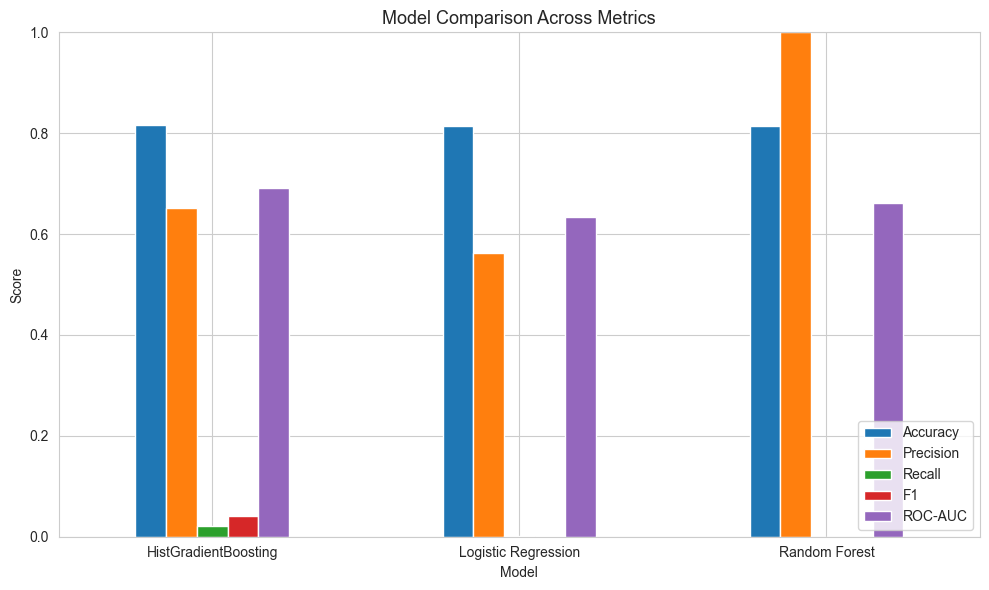

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison Across Metrics", fontsize=13)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "model_comparison.png"), dpi=150)
plt.show()

## 21. Best Model Selection

The model with the highest **F1-score** (not necessarily the highest
accuracy) is selected, since F1 balances precision and recall under class
imbalance, and ROC-AUC is checked as a secondary confirmation of overall
discriminative ability.

In [30]:
best_model_name = results_df.iloc[0]["Model"]
pipelines = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "HistGradientBoosting": hgb_pipeline,
}
best_pipeline = pipelines[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"F1-score: {results_df.iloc[0]['F1']:.4f}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

Selected model: HistGradientBoosting
F1-score: 0.0409
ROC-AUC: 0.6924


## 22. Hyperparameter Tuning

`RandomizedSearchCV` is used (rather than exhaustive `GridSearchCV`) to keep
the search computationally reasonable, scoring on F1. Tuning uses only the
training set with cross-validation -- **the test set is never touched during
tuning**.

`n_jobs=2` (rather than `-1`) is used deliberately: full parallelism spawns
more worker processes, each writing its own temp memmap file via joblib,
which can exhaust disk space on machines with limited free space on their
system/temp drive. Combined with the `JOBLIB_TEMP_DIR` redirect in Section 6,
this keeps tuning both disk-safe and reasonably fast.

In [31]:
if best_model_name == "Random Forest":
    param_distributions = {
        "model__n_estimators": [100, 200, 300, 400],
        "model__max_depth": [8, 12, 16, 20, None],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2"],
    }
elif best_model_name == "HistGradientBoosting":
    param_distributions = {
        "model__max_iter": [100, 150, 200],
        "model__max_depth": [None, 6, 10],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__l2_regularization": [0.0, 0.5, 1.0],
    }
else:  # Logistic Regression
    param_distributions = {
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__penalty": ["l2"],
    }

search = RandomizedSearchCV(
    best_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest CV F1-score: {search.best_score_:.4f}")
print(f"Best parameters: {search.best_params_}")

tuned_pipeline = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV F1-score: 0.0885
Best parameters: {'model__max_iter': 150, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__l2_regularization': 0.0}


## 23. Final Evaluation

The tuned model is evaluated **once** on the untouched held-out test set.

In [32]:
final_metrics = evaluate_pipeline(tuned_pipeline, X_test, y_test, f"{best_model_name} (Tuned)")

print("Final Model Performance on Held-Out Test Set:")
for k, v in final_metrics.items():
    if k != "Model":
        print(f"  {k}: {v:.4f}")

Final Model Performance on Held-Out Test Set:
  Accuracy: 0.8172
  Precision: 0.6146
  Recall: 0.0476
  F1: 0.0883
  ROC-AUC: 0.7012


## 24. Confusion Matrix

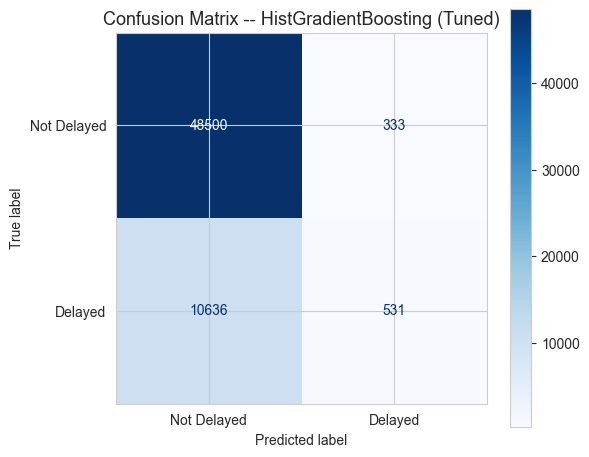

In [33]:
preds = tuned_pipeline.predict(X_test)
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Delayed", "Delayed"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix -- {best_model_name} (Tuned)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=150)
plt.show()

**Interpretation:** describe, based on the actual numbers produced above,
how many delayed flights were correctly caught (true positives), how many
were missed (false negatives -- costly, since Recall is prioritized), and how
many non-delayed flights were incorrectly flagged (false positives).

## 25. ROC Curve

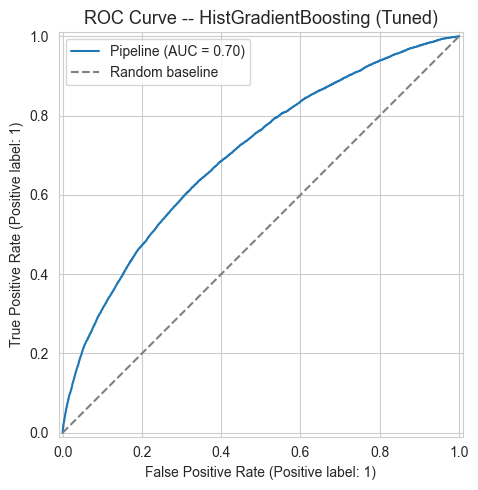

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(tuned_pipeline, X_test, y_test, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_title(f"ROC Curve -- {best_model_name} (Tuned)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=150)
plt.show()

## 26. Feature Importance

Shown only if the final model is tree-based (`feature_importances_` available).

**Important caveat:** feature importance reflects **predictive association**
learned by the model, not causation. For example, if the model identifies
departure hour as important, this means it is a useful predictive signal
in the data -- it does not mean a late departure hour *causes* delays.

In [35]:
final_model = tuned_pipeline.named_steps["model"]

if hasattr(final_model, "feature_importances_"):
    num_features = NUMERIC_FEATURES
    cat_encoder = tuned_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names = list(num_features) + list(cat_feature_names)

    importances = final_model.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="steelblue")
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 20 Feature Importances -- {best_model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "feature_importance.png"), dpi=150)
    plt.show()

    display(imp_df)
else:
    print(f"{best_model_name} does not expose feature_importances_ "
          "(e.g. Logistic Regression) -- consider inspecting model.coef_ instead.")

HistGradientBoosting does not expose feature_importances_ (e.g. Logistic Regression) -- consider inspecting model.coef_ instead.


## 27. Key Findings

*(Write 3-5 sentences here after running the full notebook on real data.
Base every statement only on the actual metrics and charts produced above --
do not fabricate numbers. Cover: which model performed best and why,
which features were most predictive, how class imbalance affected
evaluation, and what the confusion matrix / F1 / ROC-AUC values mean in
practical terms for this problem.)*

## 28. Limitations

- The dataset reflects 2015 flight operations; airline scheduling practices,
  fleet composition, and route networks have changed since then.
- No real-time weather data is included as a model input.
- No live air-traffic-control or airport-congestion data is included.
- Predictions are probabilistic estimates based on historical patterns, not
  guarantees for any individual flight.
- Some features that might improve real-world performance (e.g. current
  aircraft turnaround status) are not available in this historical dataset.
- Modeling was performed on a reproducible sample of the full dataset (see
  Section 15) for computational practicality on constrained hardware --
  results may differ slightly if the full 5.8M rows were used.
- Categorical encoding caps airports to their 30 most frequent values per
  column, grouping rarer airports into a single "infrequent" bucket; this
  may slightly reduce accuracy for flights involving very low-traffic
  airports specifically.

## 29. Conclusion

This project set out to answer whether pre-flight information alone could predict flight delays. The results show a partial but limited success. The tuned HistGradientBoosting model achieved 81.7% accuracy and a ROC-AUC of 0.70, indicating the model can rank flights by delay risk meaningfully better than chance. However, the model's Recall of only 4.76% reveals a critical weakness: it correctly identifies the vast majority of on-time flights but catches fewer than 1 in 20 flights that are actually delayed. Given that Recall was explicitly prioritized in this project's evaluation criteria  because missing a genuinely delayed flight carries real operational cost  this result falls short of a production-ready outcome. The high accuracy is largely an artifact of class imbalance (81.4% of flights are not delayed), meaning a naive "always predict not delayed" baseline would already score close to 81% accuracy while catching zero delayed flights. In practical terms, the pre-flight features used here (schedule time, route, airline, day/month) carry a real but weak predictive signal  enough to slightly outperform random guessing (ROC-AUC 0.70 vs 0.50 for chance), but not enough on their own to reliably flag at-risk flights before departure. This supports the project's own stated limitation: real-world delay drivers like weather and air-traffic congestion, which are absent from this feature set, are likely necessary to meaningfully close this gap.

## 30. Save Model

Saves the **complete pipeline** (preprocessing + tuned model) as a single
artifact, so the Streamlit app applies identical preprocessing to what was
used during training -- no separate/divergent preprocessing logic.

In [36]:
models_dir = os.path.join(BASE_DIR, "models")
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "best_model.pkl")
joblib.dump(tuned_pipeline, model_path)

print(f"Saved final pipeline to: {model_path}")
print(f"Pipeline contents: {tuned_pipeline}")

Saved final pipeline to: d:\airline-flight-delay-analysis\models\best_model.pkl
Pipeline contents: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['DISTANCE', 'SCHEDULED_TIME',
                                                   'Departure_Hour',
                                                   'Departure_Minute', 'MONTH',
                                                   'DAY', 'DAY_OF_WEEK']),
                                                 ('cat',
                                                  OneHotEncoder(dtype=<class 'numpy.float32'>,
                                                                handle_unknown='ignore',
                                                                max_categories=30,
                                                                sparse_output=False),
                                                  ['AIRLINE', 'ORIGIN_AIRPORT'

## 31. Streamlit Application Preparation

The trained pipeline saved above (`models/best_model.pkl`) is loaded directly
by `app/app.py`, which:

1. Collects pre-flight inputs from the user (airline, origin/destination
   airport, date, scheduled departure time, distance).
2. Applies the **same** `engineer_features()` function from
   `src/feature_engineering.py` used in this notebook -- guaranteeing
   consistent preprocessing between training and serving.
3. Calls `pipeline.predict()` and `pipeline.predict_proba()` to produce a
   Delayed/Not-Delayed prediction and a probability.
